                                                                                                by Maria 

# <center> Perceptron using Pytorch

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
import torch
import torchvision
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from skimage.feature import hog
import time

In [2]:
print(f"PyTorch version: {torch.__version__}, CUDA version: {torch.version.cuda}")
print(f"torchvision version: {torchvision.__version__}")

PyTorch version: 2.5.0+cu124, CUDA version: 12.4
torchvision version: 0.20.0+cu124


Задание №4
1.  Знакомство с pytorch - познакомьтесь с документацией для pytorch
(https://pytorch.org/tutorials/beginner/basics/intro.html).
2. Вам необхоидимо создать простейший перцептрон с двумя слоями и обучить его
классифицировать элементы в датасете MNIST.
3. Сравните эти результаты с работой вашего собственного перцептрона и SVC.
Проаналзируйте результаты.

# Simple 2-Layer Perceptron using Pytorch

![img](./data/img/5th/i.webp)

In [3]:
def create_hog_features(images):
    hog_features = []
    for image in images:
        fd, hog_image = hog(image, orientations=8, pixels_per_cell=(3, 3),
                    cells_per_block=(1, 1), visualize=True, channel_axis=None)
        hog_features.append(fd)
    return np.array(hog_features)

In [4]:
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = datasets.MNIST(root='./data', train=False, transform=transform, download=True)

In [5]:
X_train_hog = create_hog_features(train_dataset.data.numpy())
y_train = train_dataset.targets.numpy()

X_test_hog = create_hog_features(test_dataset.data.numpy())
y_test = test_dataset.targets.numpy()

In [6]:
X_train_hog_tensor = torch.FloatTensor(X_train_hog)
y_train_tensor = torch.LongTensor(y_train)
X_test_hog_tensor = torch.FloatTensor(X_test_hog)
y_test_tensor = torch.LongTensor(y_test)

In [1753]:
input_size = 648
hidden_size = 120
num_classes = 10 
num_epochs = 12
batch_size = 350   
learning_rate = 0.0025

In [1754]:
train_tensor_dataset = torch.utils.data.TensorDataset(X_train_hog_tensor, y_train_tensor)
test_tensor_dataset = torch.utils.data.TensorDataset(X_test_hog_tensor, y_test_tensor)

In [1755]:
train_loader = DataLoader(dataset=train_tensor_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_tensor_dataset, batch_size=batch_size, shuffle=False)

Dropout (исключение) — метод регуляризации искусственных нейронных сетей.
(https://medium.com/analytics-vidhya/a-simple-introduction-to-dropout-regularization-with-code-5279489dda1e)

Он предназначен для уменьшения переобучения сети за счёт предотвращения сложных коадаптаций отдельных нейронов на тренировочных данных во время обучения.

Dropout исключает определённый процент (например, 30 %) случайных нейронов (находящихся как в скрытых, так и в видимых слоях) на разных итерациях (эпохах) во время обучения нейронной сети.

Этот метод значительно увеличивает скорость обучения, качество обучения на тренировочных данных, а также повышает качество предсказаний модели на новых тестовых данных.

In [1756]:
class SimplePerceptron(nn.Module):
    def __init__(self):
        super(SimplePerceptron, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)  
        self.fc2 = nn.Linear(hidden_size, hidden_size)  
        self.fc3 = nn.Linear(hidden_size, num_classes) 
        self.dropout = nn.Dropout(p=0.5)

    def forward(self, x):
        x = self.dropout(torch.relu(self.fc1(x))) 
        x = self.dropout(torch.relu(self.fc2(x)))  
        x = self.fc3(x)  
        return x

In [1757]:
model = SimplePerceptron()
criterion = nn.CrossEntropyLoss() 
optimizer = optim.Adam(model.parameters(), lr=learning_rate)  

In [1758]:
train_losses = []
val_losses = []

- Входные данные проходят через два слоя с ReLU и Dropout, чтобы получить более устойчивые признаки и избежать переобучения.
- Выходной слой генерирует логиты для каждого класса, которые преобразуются в вероятности с помощью софтмакса внутри кросс-энтропийной функции потерь.
- С помощью оптимизатора (здесь — Adam) веса обновляются в направлении, которое минимизирует ошибку.
- Кросс-энтропия измеряет, насколько предсказания отличаются от истинных меток, и оптимизация на ее основе корректирует веса, чтобы минимизировать ошибку и повысить точность модели.

In [1759]:
start_time = time.time()
for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    avg_epoch_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_epoch_loss)

    model.eval()
    val_epoch_loss = 0.0
    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_epoch_loss += loss.item()
    avg_val_loss = val_epoch_loss / len(test_loader)
    val_losses.append(avg_val_loss)
    
    print(f'Epoch [{epoch + 1}/{num_epochs}], Training Loss: {avg_epoch_loss:.4f}, Validation Loss: {avg_val_loss:.4f}')
total_time = time.time() - start_time
print(f'Total fitting time: {total_time:.2f} seconds')

Epoch [1/12], Training Loss: 0.4234, Validation Loss: 0.0891
Epoch [2/12], Training Loss: 0.1402, Validation Loss: 0.0756
Epoch [3/12], Training Loss: 0.1119, Validation Loss: 0.0665
Epoch [4/12], Training Loss: 0.0977, Validation Loss: 0.0645
Epoch [5/12], Training Loss: 0.0880, Validation Loss: 0.0650
Epoch [6/12], Training Loss: 0.0813, Validation Loss: 0.0616
Epoch [7/12], Training Loss: 0.0745, Validation Loss: 0.0619
Epoch [8/12], Training Loss: 0.0697, Validation Loss: 0.0629
Epoch [9/12], Training Loss: 0.0649, Validation Loss: 0.0536
Epoch [10/12], Training Loss: 0.0639, Validation Loss: 0.0590
Epoch [11/12], Training Loss: 0.0599, Validation Loss: 0.0552
Epoch [12/12], Training Loss: 0.0573, Validation Loss: 0.0597
Total fitting time: 11.67 seconds


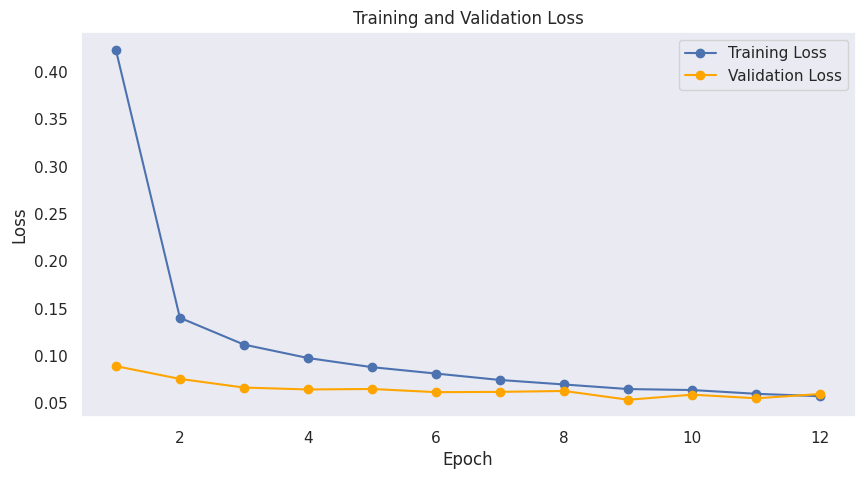

In [1760]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, num_epochs + 1), train_losses, marker='o', label='Training Loss')
plt.plot(range(1, num_epochs + 1), val_losses, marker='o', label='Validation Loss', color='orange')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()

In [1761]:
model.eval()
all_labels, all_predictions = [], []

In [1762]:
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        all_labels.extend(labels.numpy())
        all_predictions.extend(predicted.numpy())

In [1763]:
accuracy = sum(np.array(all_predictions) == np.array(all_labels)) / len(all_labels)
print(f'Accuracy: {accuracy * 100:.2f}%')

Accuracy: 98.30%


In [1764]:
report = classification_report(all_labels, all_predictions, digits=4)
print(report)

              precision    recall  f1-score   support

           0     0.9848    0.9898    0.9873       980
           1     0.9886    0.9903    0.9894      1135
           2     0.9770    0.9874    0.9822      1032
           3     0.9784    0.9871    0.9828      1010
           4     0.9877    0.9796    0.9836       982
           5     0.9832    0.9854    0.9843       892
           6     0.9895    0.9823    0.9859       958
           7     0.9787    0.9825    0.9806      1028
           8     0.9824    0.9733    0.9778       974
           9     0.9800    0.9713    0.9756      1009

    accuracy                         0.9830     10000
   macro avg     0.9830    0.9829    0.9829     10000
weighted avg     0.9830    0.9830    0.9830     10000



In [1765]:
cm = confusion_matrix(all_labels, all_predictions)

In [1766]:
def confusion_matrix_visualisation(cm):
    plt.figure(figsize=(8, 5))
    sns.heatmap(cm, square=True, annot=True, cmap='BuPu')
    plt.title('Confusion Matrix')
    plt.ylabel('Действительный класс')
    plt.xlabel('Предсказанный класс')

    plt.tight_layout()
    plt.show()

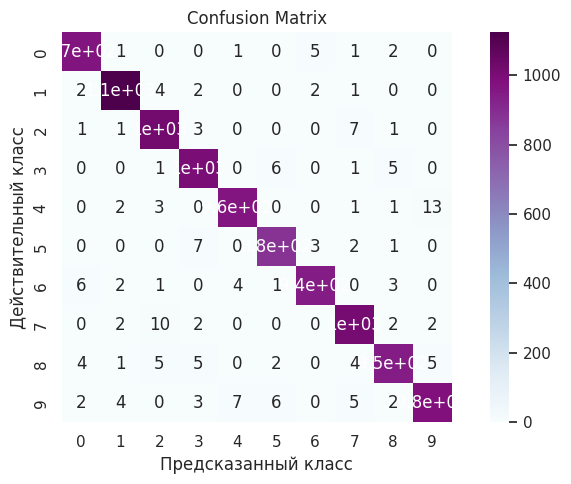

In [1767]:
confusion_matrix_visualisation(cm)

Выводы: работает очень быстро, при этом получаем хорошую точность - не хуже svc и сильно быстрее!

SVC 
 - Accuracy Score with HOG features: 0.9867857142857143
 - Fit Time 153.67591786384583 seconds

соберём всё в класс

In [1749]:
input_size = 648
hidden_size = 120
num_classes = 10 
num_epochs = 12
batch_size = 200   
learning_rate = 0.0025

In [1750]:
class SimplePerceptron(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(SimplePerceptron, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)  
        self.fc2 = nn.Linear(hidden_size, hidden_size)  
        self.fc3 = nn.Linear(hidden_size, num_classes)  
        self.dropout = nn.Dropout(p=0.5)

    def forward(self, x):
        x = self.dropout(torch.relu(self.fc1(x))) 
        x = self.dropout(torch.relu(self.fc2(x)))  
        x = self.fc3(x)  
        return x
    
    def fit(self, train_loader, val_loader, num_epochs, learning_rate):
        criterion = nn.CrossEntropyLoss() 
        optimizer = optim.Adam(self.parameters(), lr=learning_rate)  

        train_losses = []
        val_losses = []

        start_time = time.time()
        for epoch in range(num_epochs):
            self.train()  
            epoch_loss = 0.0
            for images, labels in train_loader:
                optimizer.zero_grad()  
                outputs = self(images)  
                loss = criterion(outputs, labels) 
                loss.backward() 
                optimizer.step() 
                epoch_loss += loss.item()
                
            avg_epoch_loss = epoch_loss / len(train_loader)
            train_losses.append(avg_epoch_loss) 
            print(f'Epoch [{epoch + 1}/{num_epochs}], Training Loss: {avg_epoch_loss:.4f}')
            
            self.eval() 
            val_epoch_loss = 0.0
            with torch.no_grad():  
                for images, labels in val_loader:
                    outputs = self(images)  
                    loss = criterion(outputs, labels) 
                    val_epoch_loss += loss.item()
                    
            avg_val_loss = val_epoch_loss / len(val_loader)
            val_losses.append(avg_val_loss)
            print(f'Epoch [{epoch + 1}/{num_epochs}], Validation Loss: {avg_val_loss:.4f}')

        total_time = time.time() - start_time
        print(f'Total fitting time: {total_time:.2f} seconds')
        
        self.plot_losses(train_losses, val_losses)  
        
        return train_losses, val_losses  

    def evaluate(self, test_loader):
        self.eval()  
        all_labels = []
        all_predictions = []

        with torch.no_grad():  
            for images, labels in test_loader:
                outputs = self(images)
                _, predicted = torch.max(outputs.data, 1)  
                all_labels.extend(labels.numpy())  
                all_predictions.extend(predicted.numpy())  

        accuracy = sum(np.array(all_predictions) == np.array(all_labels)) / len(all_labels)
        print(f'Accuracy: {accuracy * 100:.2f}%')

        report = classification_report(all_labels, all_predictions, digits=4)
        print(report)

        cm = confusion_matrix(all_labels, all_predictions)
        self.confusion_matrix_visualisation(cm)

    def plot_losses(self, train_losses, val_losses):
        plt.figure(figsize=(10, 5))
        plt.plot(train_losses, label='Training Loss', color='blue')
        plt.plot(val_losses, label='Validation Loss', color='orange')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.title('Training and Validation Losses')
        plt.legend()
        plt.grid()
        plt.show()

    def confusion_matrix_visualisation(self, cm):
        plt.figure(figsize=(8, 5))
        sns.heatmap(cm, square=True, annot=True, cmap='BuPu')
        plt.title('Confusion Matrix')
        plt.ylabel('Действительный класс')
        plt.xlabel('Предсказанный класс')

        plt.tight_layout()
        plt.show()

Epoch [1/12], Training Loss: 0.4302
Epoch [1/12], Validation Loss: 0.0875
Epoch [2/12], Training Loss: 0.1435
Epoch [2/12], Validation Loss: 0.0717
Epoch [3/12], Training Loss: 0.1113
Epoch [3/12], Validation Loss: 0.0695
Epoch [4/12], Training Loss: 0.0982
Epoch [4/12], Validation Loss: 0.0620
Epoch [5/12], Training Loss: 0.0876
Epoch [5/12], Validation Loss: 0.0621
Epoch [6/12], Training Loss: 0.0808
Epoch [6/12], Validation Loss: 0.0593
Epoch [7/12], Training Loss: 0.0746
Epoch [7/12], Validation Loss: 0.0583
Epoch [8/12], Training Loss: 0.0717
Epoch [8/12], Validation Loss: 0.0560
Epoch [9/12], Training Loss: 0.0673
Epoch [9/12], Validation Loss: 0.0607
Epoch [10/12], Training Loss: 0.0634
Epoch [10/12], Validation Loss: 0.0591
Epoch [11/12], Training Loss: 0.0595
Epoch [11/12], Validation Loss: 0.0601
Epoch [12/12], Training Loss: 0.0577
Epoch [12/12], Validation Loss: 0.0559
Total fitting time: 11.92 seconds


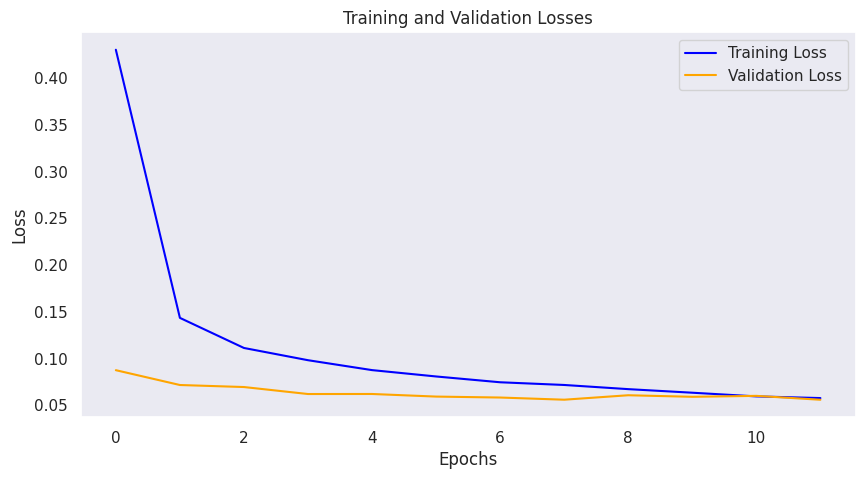

Total fitting time: 12.11 seconds


In [1751]:
model = SimplePerceptron(input_size, hidden_size, num_classes)
start_time = time.time()
train_losses, val_losses = model.fit(train_loader, test_loader, num_epochs, learning_rate)
total_time = time.time() - start_time
print(f'Total fitting time: {total_time:.2f} seconds')

Accuracy: 98.35%
              precision    recall  f1-score   support

           0     0.9819    0.9939    0.9878       980
           1     0.9843    0.9912    0.9877      1135
           2     0.9788    0.9855    0.9821      1032
           3     0.9841    0.9822    0.9832      1010
           4     0.9887    0.9796    0.9841       982
           5     0.9866    0.9922    0.9894       892
           6     0.9916    0.9802    0.9858       958
           7     0.9824    0.9757    0.9790      1028
           8     0.9815    0.9795    0.9805       974
           9     0.9762    0.9752    0.9757      1009

    accuracy                         0.9835     10000
   macro avg     0.9836    0.9835    0.9835     10000
weighted avg     0.9835    0.9835    0.9835     10000



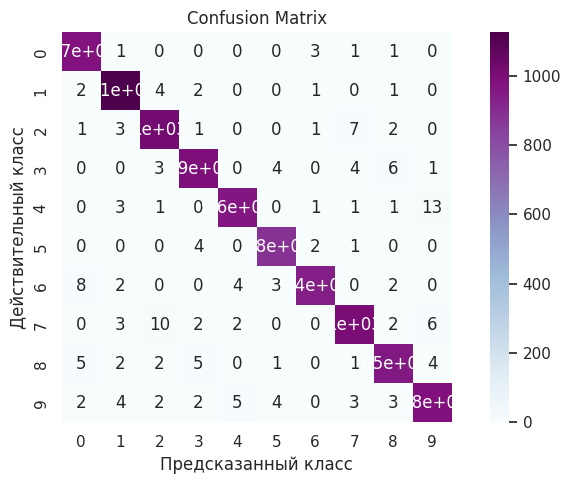

In [1752]:
model.evaluate(test_loader)